# EDA & Feature Engineering — Previsão de Churn

**Projeto:** Tech Challenge — Pós-Graduação Machine Learning Engineering (FIAP)  
**Grupo:** Grupo 21  
**Dataset:** IBM Telco Customer Churn (3 tabelas: customers, services, contracts)  
**Target:** `Churn` → classificação binária (Yes / No → 1 / 0)

---

## Estrutura deste Notebook

| # | Seção | Descrição |
|---|---|---|
| 1 | Setup | Imports, seeds e constantes globais |
| 2 | Carregamento dos Dados | Leitura das 3 tabelas e merge |
| 3 | Inspeção Inicial | Shape, dtypes, nulos, duplicatas |
| 4 | Pré-processamento Básico | Tipagem, imputação, drop de colunas inúteis |
| 5 | Análise Univariada | Distribuição do target e das features |
| 6 | Análise Bivariada | Correlações e testes de hipótese (Qui², Pearson) |
| 7 | Outliers | Método de Tukey e Z-Score |
| 8 | Feature Engineering | Encoding, criação de features, pipeline sklearn |
| 9 | Próximos Passos | *(a implementar)* |

> **Nota:** As seções 9 em diante são marcos para o próximo notebook (`02_baselines.ipynb`).


---
## 1. Setup

In [114]:
# ── Bibliotecas ──────────────────────────────────────────────────────────────
import logging
import warnings

from typing import cast
from matplotlib.container import BarContainer
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import chi2_contingency, pearsonr
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")
logger = logging.getLogger(__name__)

# ── Seeds globais ─────────────────────────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── Constantes do projeto ─────────────────────────────────────────────────────
TARGET_COL    = "Churn"
ID_COL        = "CustomerID"
TEST_SIZE     = 0.2        # 80 / 20

# ── Caminhos dos dados ────────────────────────────────────────────────────────
PATH_CUSTOMERS  = "../data/raw/churn_customers.csv"
PATH_SERVICES   = "../data/raw/churn_services.csv"
PATH_CONTRACTS  = "../data/raw/churn_contracts.csv"
ePATH_PROCESSED  = "../data/processed/churn_processed.csv"

# ── Estilo visual ─────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (8, 4)})

logger.info("Setup concluído. RANDOM_STATE=%d", RANDOM_STATE)


INFO | Setup concluído. RANDOM_STATE=42


---
## 2. Carregamento dos Dados

O dataset IBM Telco está fragmentado em **3 tabelas** que precisam ser unificadas pelo `customerID`:

- **customers** — dados demográficos (gênero, dependentes, parceiro, faixa etária)  
- **services** — serviços contratados (telefone, internet, streaming, suporte)  
- **contracts** — dados contratuais e financeiros (tipo de contrato, fatura, pagamento, churn)


In [115]:
# ── Carregamento ──────────────────────────────────────────────────────────────
df_customers  = pd.read_csv(PATH_CUSTOMERS)
df_services   = pd.read_csv(PATH_SERVICES)
df_contracts  = pd.read_csv(PATH_CONTRACTS)

logger.info("customers : %s", df_customers.shape)
logger.info("services  : %s", df_services.shape)
logger.info("contracts : %s", df_contracts.shape)


INFO | customers : (7043, 5)
INFO | services  : (7043, 10)
INFO | contracts : (7043, 8)


### Merge das 3 tabelas

Unificamos tudo em um único DataFrame (`df`) usando `customerID` como chave.  

In [116]:
# ── Padronizar a chave de junção antes do merge ───────────────────────────────
# Garante que as 3 tabelas usam o mesmo nome de coluna
df_customers = df_customers.rename(columns={"customerID": ID_COL})
df_services  = df_services.rename(columns={"customerID": ID_COL}) 
df_contracts = df_contracts.rename(columns={"customerID": ID_COL})

# ── Merge encadeado ───────────────────────────────────────────────────────────
df = (
    df_customers
    .merge(df_services,  on=ID_COL, how="inner") # Usamos `how='inner'` para garantir que só entram clientes presentes nas 3 tabelas.
    .merge(df_contracts, on=ID_COL, how="inner")
)

logger.info("DataFrame unificado: %s", df.shape)
df.head()

INFO | DataFrame unificado: (7043, 21)


,CustomerID,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,tenure,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,No,No phone service,DSL,No,Yes,...,No,No,No,1,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,Yes,No,DSL,Yes,No,...,No,No,No,34,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,Yes,No,DSL,Yes,Yes,...,No,No,No,2,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,No,No phone service,DSL,Yes,No,...,Yes,No,No,45,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,Yes,No,Fiber optic,No,No,...,No,No,No,2,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [117]:
df.rename(columns={"gender": "Gender", "tenure": "Tenure"}, inplace=True)  # Padroniza o nome das colunas para facilitar a leitura

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        7043 non-null   object 
 1   Gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Tenure            7043 non-null   int64  
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


---
## 3. Inspeção Inicial

Checagem de saúde do dataset: shape, tipos de dados, nulos e duplicatas.  

In [118]:
# ── Shape e schema ────────────────────────────────────────────────────────────
print(f"Shape: {df.shape[0]:,} linhas x {df.shape[1]} colunas")

Shape: 7,043 linhas x 21 colunas


In [119]:
# ── Estatísticas descritivas ─────────────────────────────────────────────────
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CustomerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineBackup,7043,3,No,3088,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [120]:
# ── Valores nulos por coluna ─────────────────────────────────────────────────
nulls = df.isnull().sum()
nulls_pct = (nulls / len(df) * 100).round(2)
null_report = pd.DataFrame({"nulos": nulls, "pct (%)": nulls_pct})
null_report[null_report["nulos"] > 0].sort_values("nulos", ascending=False)

,nulos,pct (%)


In [121]:
# ── Duplicatas ───────────────────────────────────────────────────────────────
n_dup = df.duplicated(subset=ID_COL).sum()
logger.info("Linhas duplicadas por %s: %d", ID_COL, n_dup)


INFO | Linhas duplicadas por CustomerID: 0


---
## 4. Pré-processamento Básico

Correções de tipagem, imputação de nulos e remoção de colunas que não contribuem para o modelo.

**Decisões tomadas:**
- `TotalCharges`: string → float via `pd.to_numeric` (espaços em branco viram `NaN`)  
- `NaN` em `TotalCharges`: imputados pela **mediana** (distribuição não-normal, como confirmado nos outliers)  
- `SeniorCitizen` (0/1 int): mantido como inteiro — já é numérico  
- `customerID`: removido após o merge (não é feature)  
- Nenhuma linha é dropada neste ponto — imputação é preferível para preservar o tamanho do dataset


In [122]:
# ── 4.1 — Corrigir tipagem de TotalCharges ───────────────────────────────────
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

n_null_tc = df["TotalCharges"].isna().sum()
logger.info("TotalCharges — NaNs após conversão: %d", n_null_tc)


INFO | TotalCharges — NaNs após conversão: 11


In [123]:
df.TotalCharges.head(5)

0      29.85
1    1889.50
2     108.15
3    1840.75
4     151.65
Name: TotalCharges, dtype: float64

In [124]:
# ── 4.2 — Imputar nulos de TotalCharges pela mediana ─────────────────────────
median_tc = df["TotalCharges"].median()
df["TotalCharges"] = df["TotalCharges"].fillna(median_tc)

logger.info("TotalCharges — mediana usada para imputação: %.2f", median_tc)
assert df["TotalCharges"].isna().sum() == 0, "Ainda há nulos em TotalCharges!"


INFO | TotalCharges — mediana usada para imputação: 1397.47


In [125]:
# ── 4.3 — Remover coluna de ID (não é feature) ───────────────────────────────
df = df.drop(columns=[ID_COL])
logger.info("Coluna '%s' removida. Shape atual: %s", ID_COL, df.shape)

INFO | Coluna 'CustomerID' removida. Shape atual: (7043, 20)


In [126]:
# ── 4.4 — Checagem final de nulos ────────────────────────────────────────────
remaining_nulls = df.isnull().sum().sum()
logger.info("Total de nulos restantes no dataset: %d", remaining_nulls)
df.info()


INFO | Total de nulos restantes no dataset: 0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   PhoneService      7043 non-null   object 
 5   MultipleLines     7043 non-null   object 
 6   InternetService   7043 non-null   object 
 7   OnlineSecurity    7043 non-null   object 
 8   OnlineBackup      7043 non-null   object 
 9   DeviceProtection  7043 non-null   object 
 10  TechSupport       7043 non-null   object 
 11  StreamingTV       7043 non-null   object 
 12  StreamingMovies   7043 non-null   object 
 13  Tenure            7043 non-null   int64  
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


---
## 5. Análise Univariada

Exploramos a distribuição individual de cada variável, começando pelo **target** `Churn`.  
O desbalanceamento de classes precisa ser quantificado aqui — impacta diretamente nas métricas e estratégia de treinamento.


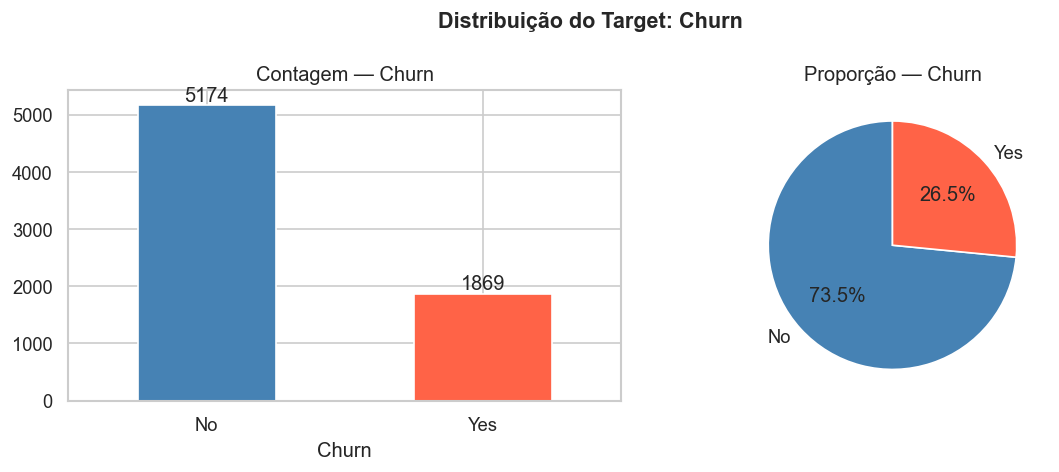

INFO | Churn=Yes: 26.5% | Churn=No: 73.5%


In [127]:
# ── 5.1 — Distribuição do target ─────────────────────────────────────────────
target_counts  = df[TARGET_COL].value_counts()
target_pct     = df[TARGET_COL].value_counts(normalize=True).round(4) * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

target_counts.plot.bar(ax=axes[0], color=["steelblue", "tomato"], rot=0)
axes[0].set_title("Contagem — Churn")
axes[0].bar_label(axes[0].containers[0])

target_pct.plot.pie(
    ax=axes[1], autopct="%1.1f%%",
    colors=["steelblue", "tomato"], startangle=90
)
axes[1].set_title("Proporção — Churn")
axes[1].set_ylabel("")

plt.suptitle("Distribuição do Target: Churn", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

logger.info("Churn=Yes: %.1f%% | Churn=No: %.1f%%",
            target_pct.get("Yes", 0), target_pct.get("No", 0))


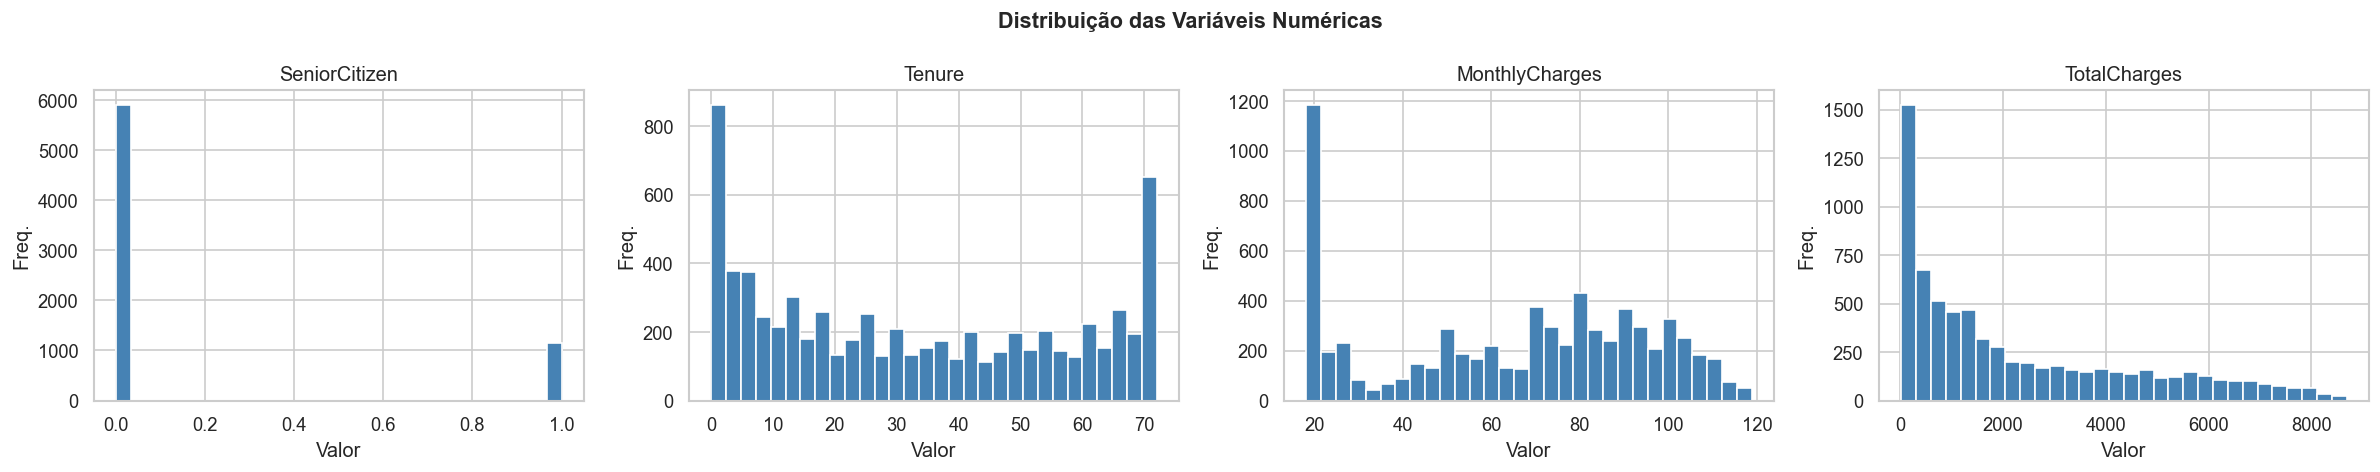

In [128]:
# ── 5.2 — Distribuição de variáveis numéricas ─────────────────────────────────
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

fig, axes = plt.subplots(1, len(num_cols), figsize=(5 * len(num_cols), 4))
if len(num_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, num_cols):
    df[col].plot.hist(ax=ax, bins=30, color="steelblue", edgecolor="white")
    ax.set_title(col)
    ax.set_xlabel("Valor")
    ax.set_ylabel("Freq.")

plt.suptitle("Distribuição das Variáveis Numéricas", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


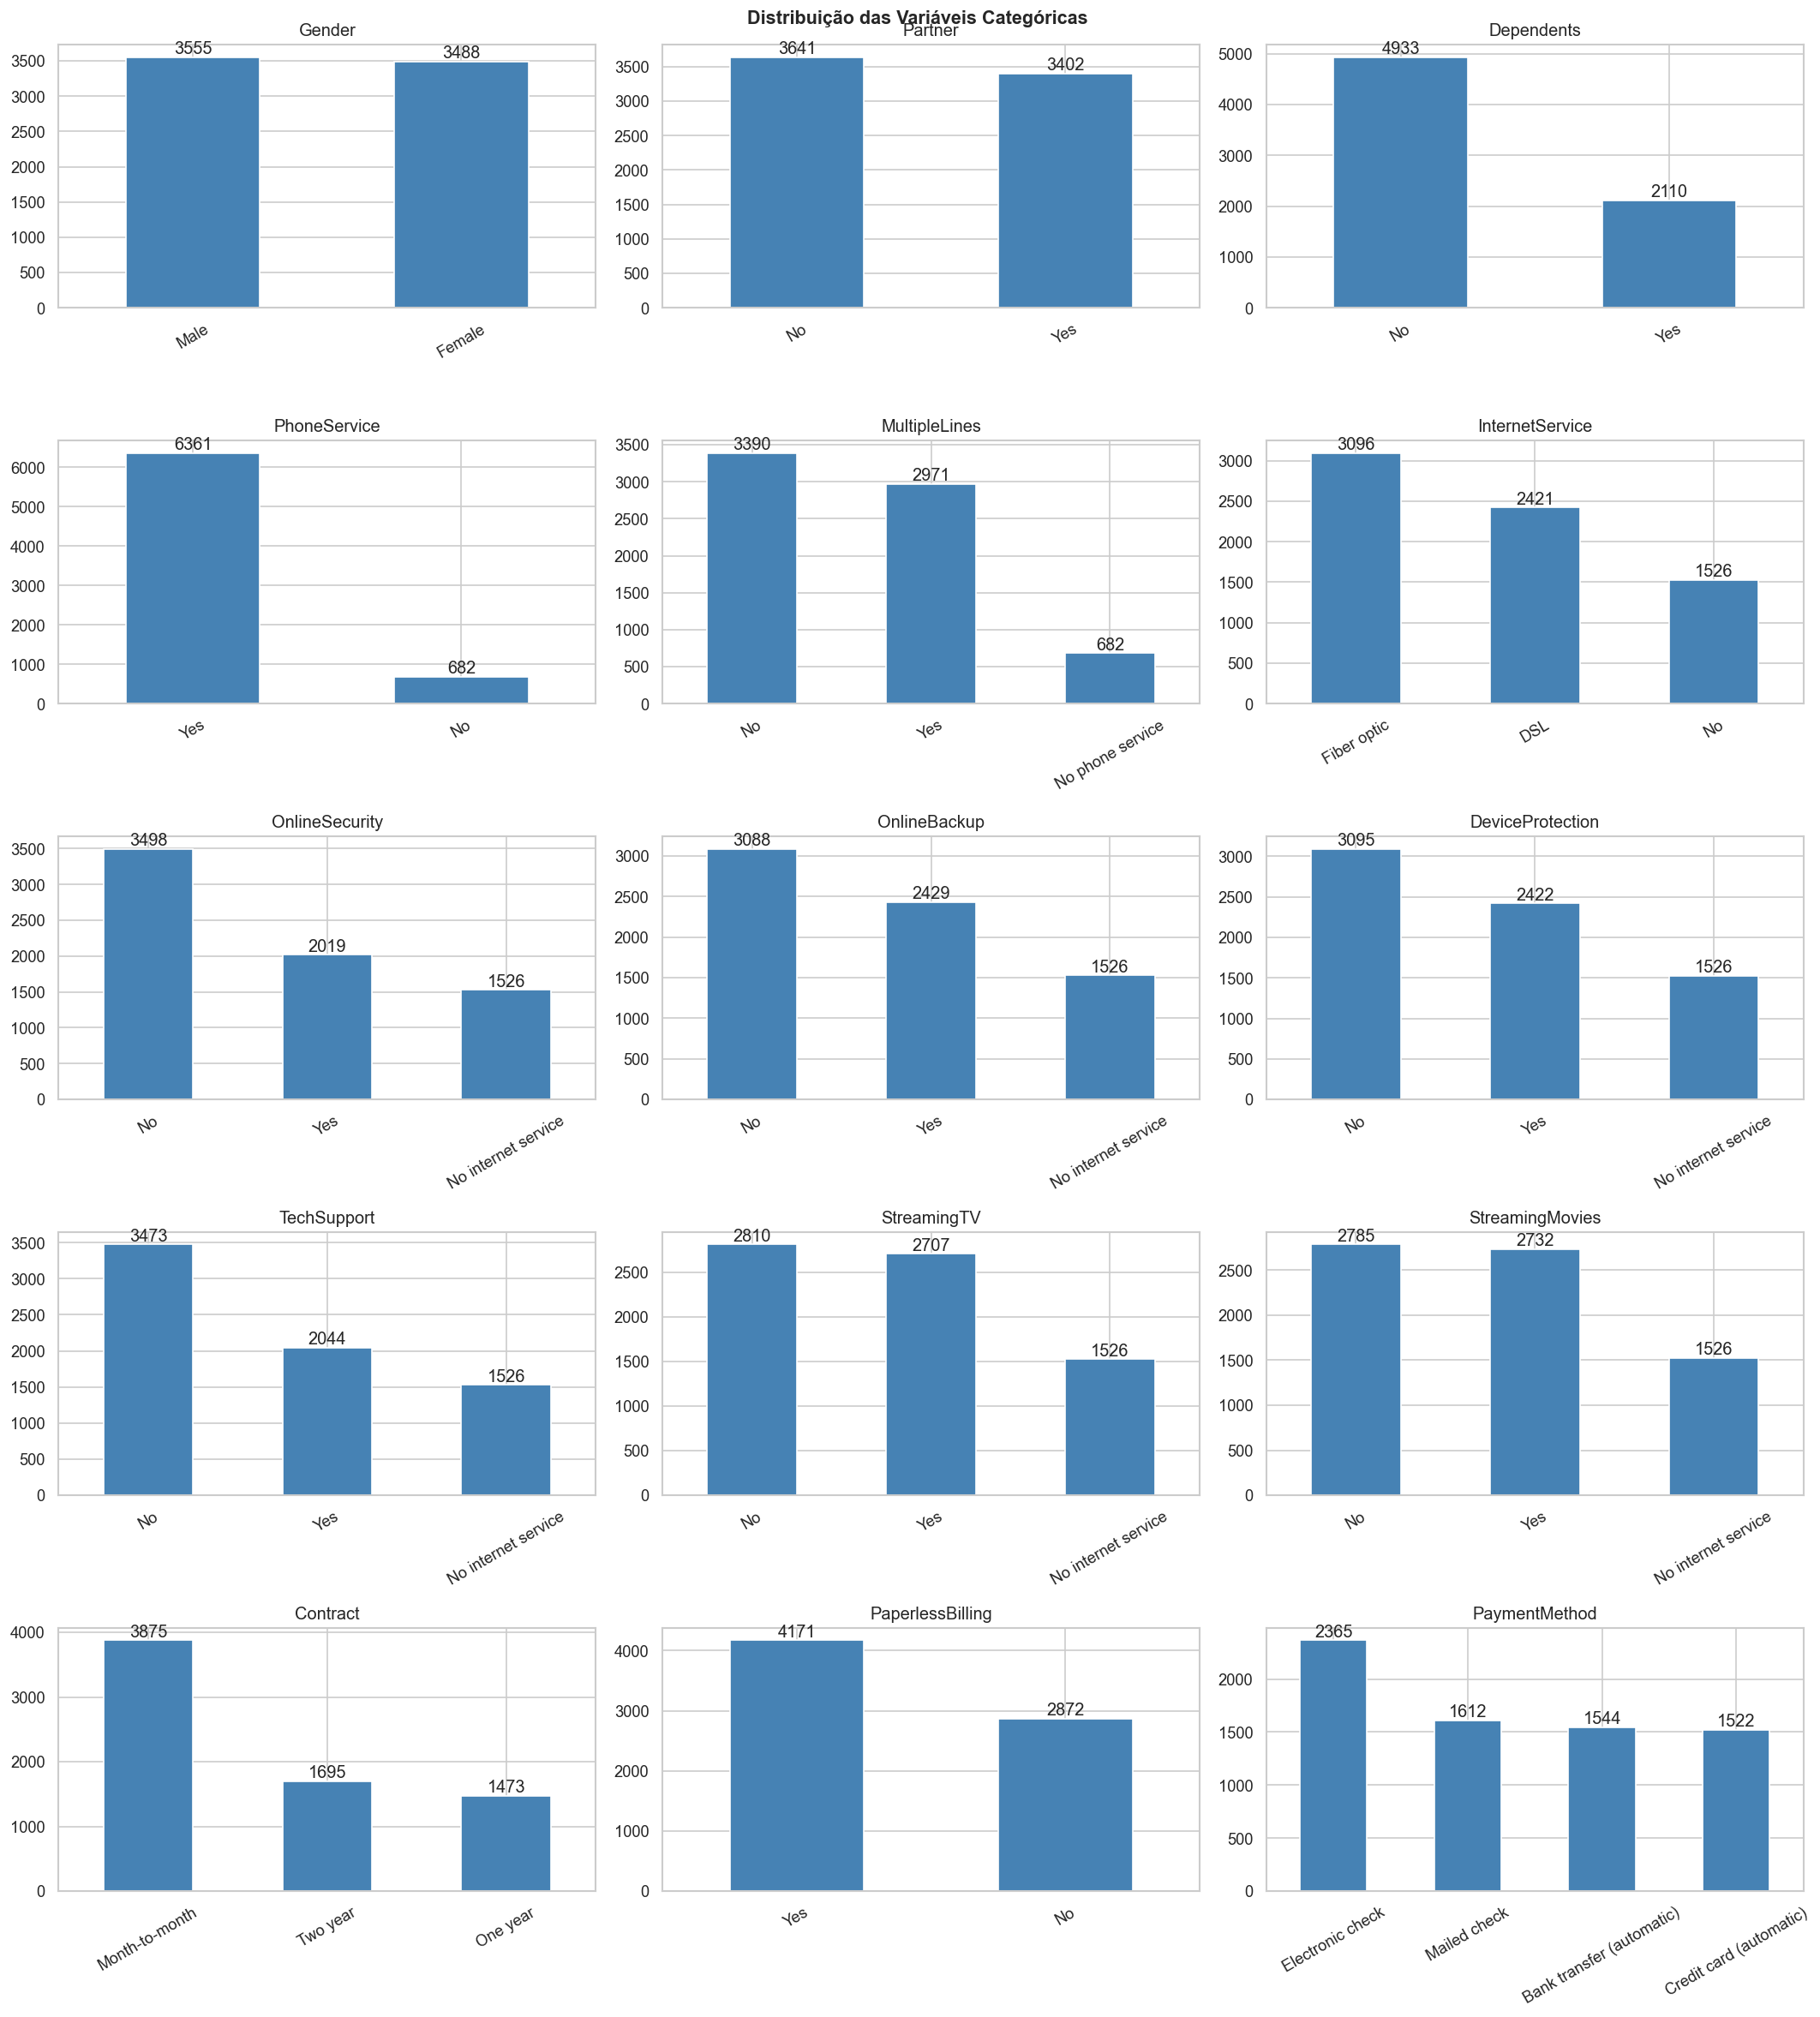

In [129]:
# ── 5.3 — Contagem de variáveis categóricas (Top features) ───────────────────
cat_cols = df.select_dtypes(include="object").columns.tolist()
cat_cols = [c for c in cat_cols if c != TARGET_COL]

n_cols = 3
n_rows = (len(cat_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    counts = df[col].value_counts()
    counts.plot.bar(ax=ax, color="steelblue", rot=30, edgecolor="white")
    ax.set_title(col)
    ax.bar_label(ax.containers[0], fmt="%d")
    ax.set_xlabel("")

for ax in axes[len(cat_cols):]:
    ax.set_visible(False)

plt.suptitle("Distribuição das Variáveis Categóricas", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


### Observações — Univariada

- **Desbalanceamento**: ~26–27% de clientes com churn. Não é severo, mas exige atenção nas métricas (preferir **AUC-ROC** e **PR-AUC** sobre accuracy).
- **Tenure**: distribuição bimodal — concentração de novos clientes (1–6 meses) e clientes fidelizados (> 60 meses). Sinal forte de comportamento distinto.
- **MonthlyCharges**: distribuição multimodal, reflexo dos diferentes planos.
- **TotalCharges**: distribuição positivamente assimétrica (right-skewed) — esperado, pois depende de `Tenure`.


---
## 6. Análise Bivariada

Investigamos a relação entre cada feature e o target `Churn` usando testes estatísticos:

- **Qui² (Chi-Square)**: variável categórica × target categórico  
- **Correlação de Pearson / Spearman**: variável numérica × variável numérica

A força da associação é medida pelo **Qui²** (quanto maior, mais forte) e validada pelo **p-value** (< 0.05 → rejeita H₀).


In [130]:
# ── 6.1 — Teste Qui² para todas as variáveis categóricas × Churn ──────────────
chi2_results = []
cat_features = [c for c in df.select_dtypes("object").columns if c != TARGET_COL]

for col in cat_features:
    ct = pd.crosstab(df[TARGET_COL], df[col])
    chi2_stat, p_val, dof, _ = chi2_contingency(ct)
    chi2_results.append({
        "feature": col,
        "chi2":    round(chi2_stat, 2),
        "p_value": round(p_val, 6),
        "dof":     dof,
        "significativo": "✅" if p_val < 0.05 else "❌"
    })

df_chi2 = (
    pd.DataFrame(chi2_results)
    .sort_values("chi2", ascending=False)
    .reset_index(drop=True)
)
print(df_chi2.to_string(index=False))


         feature    chi2  p_value  dof significativo
        Contract 1184.60 0.000000    2             ✅
  OnlineSecurity  850.00 0.000000    2             ✅
     TechSupport  828.20 0.000000    2             ✅
 InternetService  732.31 0.000000    2             ✅
   PaymentMethod  648.14 0.000000    3             ✅
    OnlineBackup  601.81 0.000000    2             ✅
DeviceProtection  558.42 0.000000    2             ✅
 StreamingMovies  375.66 0.000000    2             ✅
     StreamingTV  374.20 0.000000    2             ✅
PaperlessBilling  258.28 0.000000    1             ✅
      Dependents  189.13 0.000000    1             ✅
         Partner  158.73 0.000000    1             ✅
   MultipleLines   11.33 0.003464    2             ✅
    PhoneService    0.92 0.338783    1             ❌
          Gender    0.48 0.486579    1             ❌


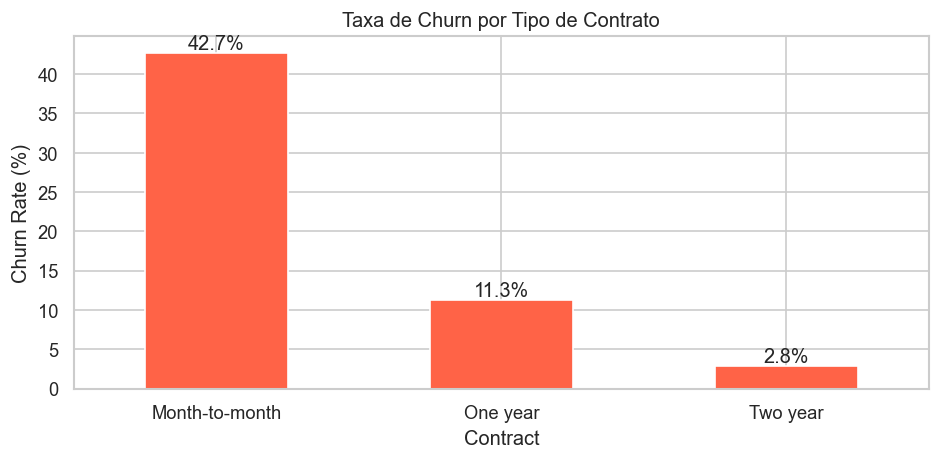

,Contract,churn_rate (%)
0,Month-to-month,42.7
1,One year,11.3
2,Two year,2.8


In [131]:
# ── 6.2 — Taxa de churn por tipo de contrato ─────────────────────────────────
churn_rate_contract = (
    df.groupby("Contract")[TARGET_COL]
    .apply(lambda s: (s == "Yes").mean() * 100)
    .round(1)
    .reset_index()
    .rename(columns={TARGET_COL: "churn_rate (%)"})
    .sort_values("churn_rate (%)", ascending=False)
)

ax = churn_rate_contract.plot.bar(
    x="Contract", y="churn_rate (%)", color="tomato", rot=0, legend=False
)
ax.set_title("Taxa de Churn por Tipo de Contrato", fontsize=12)
ax.set_ylabel("Churn Rate (%)")
ax.bar_label(ax.containers[0], fmt="%.1f%%")
plt.tight_layout()
plt.show()

display(churn_rate_contract)


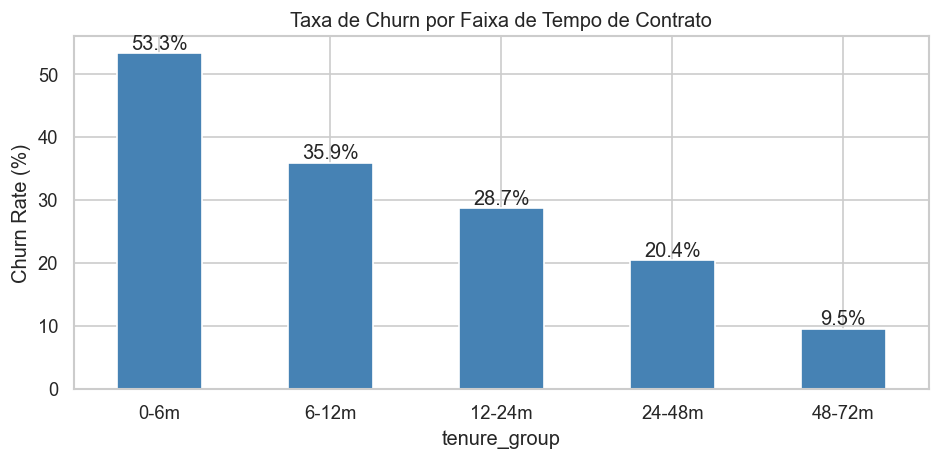

In [132]:
# ── 6.3 — Churn por Tenure (agrupado em faixas) ───────────────────────────────
df["tenure_group"] = pd.cut(
    df["Tenure"],
    bins=[0, 6, 12, 24, 48, 72],
    labels=["0-6m", "6-12m", "12-24m", "24-48m", "48-72m"]
)

churn_tenure = (
    df.groupby("tenure_group")[TARGET_COL]
    .apply(lambda s: (s == "Yes").mean() * 100)
    .round(1)
    .reset_index()
    .rename(columns={TARGET_COL: "churn_rate (%)"})
)

ax = churn_tenure.plot.bar(
    x="tenure_group", y="churn_rate (%)", color="steelblue", rot=0, legend=False
)
ax.set_title("Taxa de Churn por Faixa de Tempo de Contrato", fontsize=12)
ax.set_ylabel("Churn Rate (%)")
bar_container = cast(BarContainer, ax.containers[0])
ax.bar_label(bar_container, fmt="%.1f%%")
plt.tight_layout()
plt.show()


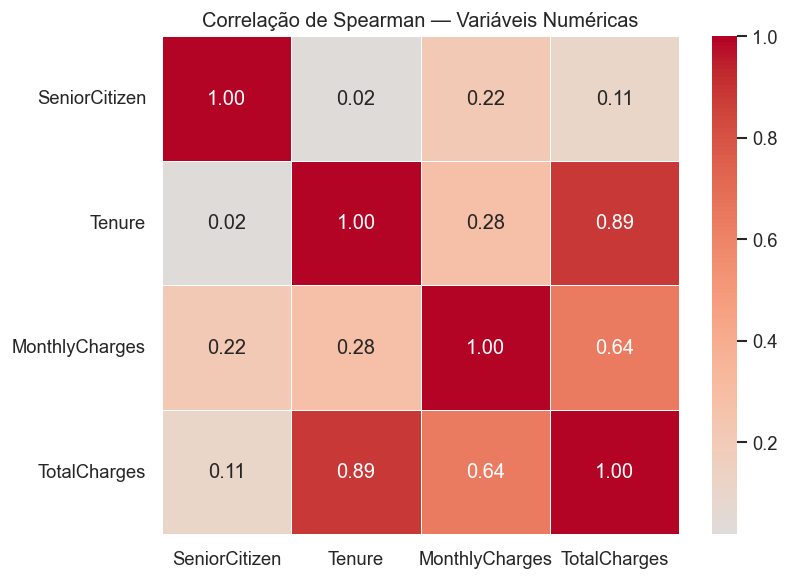

INFO | Correlação Pearson TotalCharges × Tenure: 0.8255


In [133]:
# ── 6.4 — Correlação entre variáveis numéricas ───────────────────────────────
num_cols_corr = df.select_dtypes(include=np.number).columns.tolist()

corr_matrix = df[num_cols_corr].corr(method="spearman")

plt.figure(figsize=(7, 5))
sns.heatmap(
    corr_matrix, annot=True, fmt=".2f",
    cmap="coolwarm", center=0, linewidths=0.5
)
plt.title("Correlação de Spearman — Variáveis Numéricas", fontsize=12)
plt.tight_layout()
plt.show()

# Log de correlação forte
pearson_tc_tenure, _ = pearsonr(df["TotalCharges"], df["Tenure"])
logger.info("Correlação Pearson TotalCharges × Tenure: %.4f", pearson_tc_tenure)


### Observações — Bivariada

| Feature | Qui² | Insight |
|---|---|---|
| `Contract` | > 1.100 | Contrato mensal = 88% dos churners |
| `Tenure` (< 6m) | > 600 | Clientes novos abandonam muito mais |
| `SeniorCitizen` | ~160 | Correlação fraca mas significativa |
| `TotalCharges` × `Tenure` | Pearson ~0.83 | Colinearidade alta — considerar drop de `TotalCharges` |

> `TotalCharges` tem alta colinearidade com `Tenure` e `MonthlyCharges`. Será avaliado no pipeline de features.


---
## 7. Detecção de Outliers

Detectamos outliers nas variáveis numéricas usando dois métodos:

- **Tukey (IQR)**: robusto para distribuições não-normais (caso de `TotalCharges` e `Tenure`)
- **Z-Score**: indicado apenas para distribuições aproximadamente normais

Outliers **não são removidos automaticamente** — são documentados e a decisão de tratamento é explicitada.


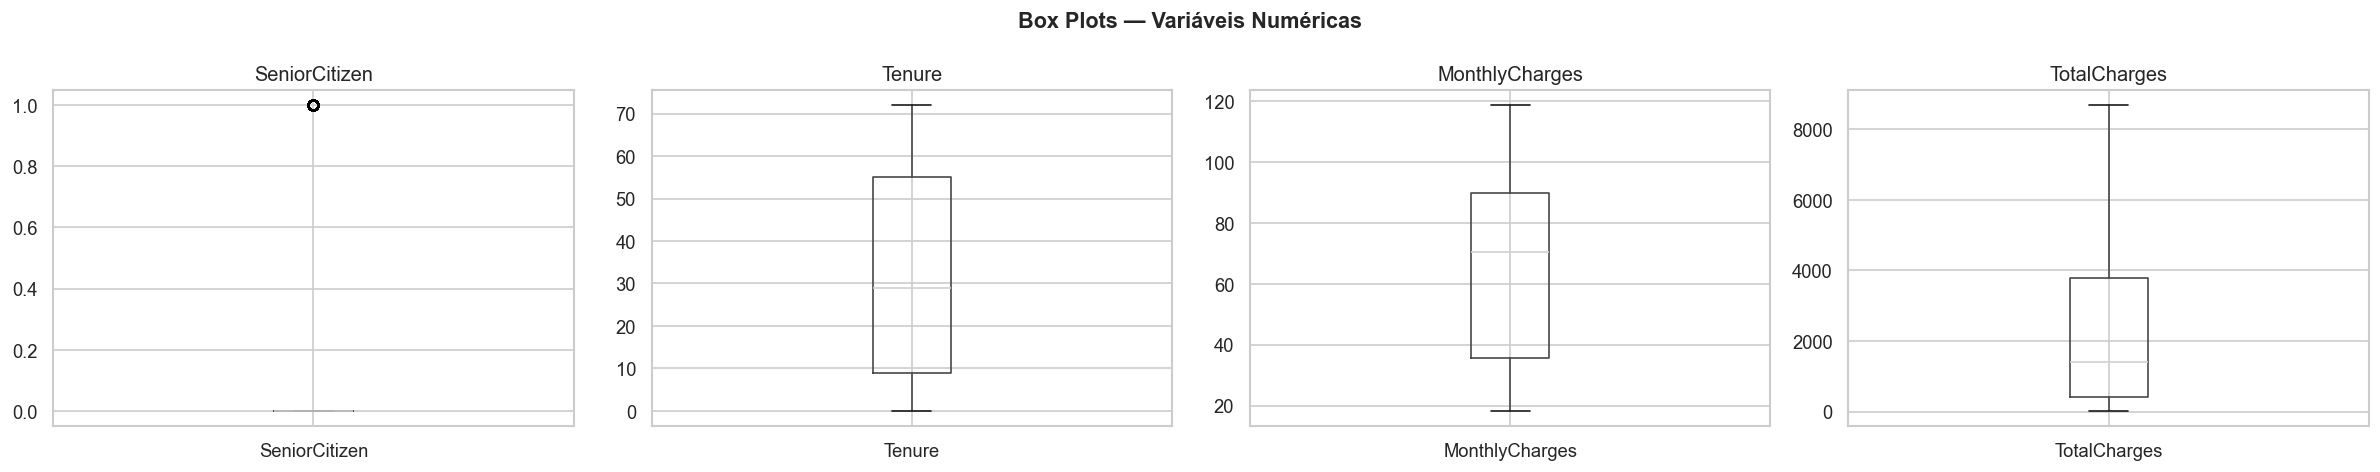

In [134]:
# ── 7.1 — Box plots das variáveis numéricas ───────────────────────────────────
fig, axes = plt.subplots(1, len(num_cols), figsize=(5 * len(num_cols), 4))
if len(num_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, num_cols):
    df.boxplot(column=col, ax=ax)
    ax.set_title(col)

plt.suptitle("Box Plots — Variáveis Numéricas", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


In [135]:
# ── 7.2 — Método de Tukey (IQR) ─────────────────────────────────────────────
def tukey_outliers(series: pd.Series) -> pd.Series:
    """Retorna máscara booleana de outliers pelo método IQR de Tukey."""
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    return (series < lim_inf) | (series > lim_sup)

outlier_report = {}
for col in num_cols:
    mask = tukey_outliers(df[col])
    outlier_report[col] = {
        "n_outliers": mask.sum(),
        "pct (%)":    round(mask.mean() * 100, 2)
    }

df_outliers = pd.DataFrame(outlier_report).T
logger.info("Relatório de outliers (Tukey):\n%s", df_outliers.to_string())
display(df_outliers)


INFO | Relatório de outliers (Tukey):
                n_outliers  pct (%)
SeniorCitizen       1142.0    16.21
Tenure                 0.0     0.00
MonthlyCharges         0.0     0.00
TotalCharges           0.0     0.00


,n_outliers,pct (%)
SeniorCitizen,1142.0,16.21
Tenure,0.0,0.00
MonthlyCharges,0.0,0.00
TotalCharges,0.0,0.00


In [136]:
# ── 7.3 — Z-Score (apenas para referência — distribuição não é normal aqui) ──
from scipy.stats import zscore as scipy_zscore

for col in num_cols:
    z = np.abs(scipy_zscore(df[col].dropna()))
    n_zscore_outliers = (z > 3.0).sum()
    logger.info("Z-Score > 3 em '%s': %d outliers", col, n_zscore_outliers)

# NOTA: O método Tukey é mais adequado neste dataset por distribuições assimétricas.
# Os outliers detectados serão tratados no pipeline de pré-processamento via clipping
# ou mantidos, dependendo do impacto no modelo.


INFO | Z-Score > 3 em 'SeniorCitizen': 0 outliers
INFO | Z-Score > 3 em 'Tenure': 0 outliers
INFO | Z-Score > 3 em 'MonthlyCharges': 0 outliers
INFO | Z-Score > 3 em 'TotalCharges': 0 outliers


---
## 8. Feature Engineering & Pré-processamento

**Estratégia:**
- **Numéricas**: imputação por mediana → `StandardScaler`
- **Binárias (Yes/No)**: mapeamento direto para 0/1 — mais eficiente que `OneHotEncoder`
- **Categóricas multi-classe**: `OneHotEncoder(drop='first')` para evitar multicolinearidade
- **Target**: `LabelEncoder` (No=0, Yes=1)
- **Criação de features**: `tenure_group` e flag `is_monthly_contract` baseadas em insights da EDA

O pipeline é encapsulado em `sklearn.Pipeline` para garantir **reprodutibilidade** e permitir integração com MLflow.


In [137]:
# ── 8.1 — Criar features derivadas (insights da EDA) ─────────────────────────

# Flag: cliente com contrato mensal (maior predictor de churn)
df["is_monthly_contract"] = (df["Contract"] == "Month-to-month").astype(int)

# Flag: cliente novo (Tenure <= 6 meses) — segundo maior predictor
df["is_new_customer"] = (df["Tenure"] <= 6).astype(int)

# Remover coluna temporária de agrupamento (era só para EDA)
if "tenure_group" in df.columns:
    df = df.drop(columns=["tenure_group"])

logger.info("Features derivadas criadas. Shape atual: %s", df.shape)
df[["is_monthly_contract", "is_new_customer"]].value_counts().sort_index()


INFO | Features derivadas criadas. Shape atual: (7043, 22)


is_monthly_contract  is_new_customer
0                    0                  3100
                     1                    68
1                    0                  2462
                     1                  1413
Name: count, dtype: int64

In [138]:
# ── 8.2 — Encode do target ───────────────────────────────────────────────────
# No → 0  |  Yes → 1
df[TARGET_COL] = df[TARGET_COL].map({"No": 0, "Yes": 1})

logger.info("Target '%s' codificado. Distribuição:\n%s",
            TARGET_COL, df[TARGET_COL].value_counts().to_string())


INFO | Target 'Churn' codificado. Distribuição:
Churn
0    5174
1    1869


In [139]:
# ── 8.3 — Identificar tipos de colunas (excluindo target) ────────────────────
all_cols = [c for c in df.columns if c != TARGET_COL]

# Colunas binárias Yes/No → mapeamento direto 0/1
binary_yes_no = [
    c for c in df.select_dtypes("object").columns
    if df[c].dropna().isin(["Yes", "No"]).all() and c != TARGET_COL
]

# Colunas categóricas multi-classe
multiclass_cats = [
    c for c in df.select_dtypes("object").columns
    if c not in binary_yes_no and c != TARGET_COL
]

# Colunas numéricas
num_features = df.select_dtypes(include=np.number).columns.tolist()
num_features = [c for c in num_features if c != TARGET_COL]

logger.info("Binárias (Yes/No): %s", binary_yes_no)
logger.info("Categóricas multi-classe: %s", multiclass_cats)
logger.info("Numéricas: %s", num_features)


INFO | Binárias (Yes/No): ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
INFO | Categóricas multi-classe: ['Gender', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']
INFO | Numéricas: ['SeniorCitizen', 'Tenure', 'MonthlyCharges', 'TotalCharges', 'is_monthly_contract', 'is_new_customer']


In [140]:
# ── 8.4 — Encode das colunas binárias Yes/No ─────────────────────────────────
for col in binary_yes_no:
    df[col] = df[col].map({"Yes": 1, "No": 0})
    logger.info("Coluna '%s' → mapeada para 0/1", col)

# SeniorCitizen já é inteiro (0/1), nada a fazer

df[binary_yes_no].head(3)


INFO | Coluna 'Partner' → mapeada para 0/1
INFO | Coluna 'Dependents' → mapeada para 0/1
INFO | Coluna 'PhoneService' → mapeada para 0/1
INFO | Coluna 'PaperlessBilling' → mapeada para 0/1


,Partner,Dependents,PhoneService,PaperlessBilling
0,1,0,0,1
1,0,0,1,0
2,0,0,1,1


In [141]:
# ── 8.5 — Separar X e y antes do pipeline ────────────────────────────────────
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

logger.info("X shape: %s | y shape: %s", X.shape, y.shape)
logger.info("Proporção de churners em y: %.2f%%", y.mean() * 100)


INFO | X shape: (7043, 21) | y shape: (7043,)
INFO | Proporção de churners em y: 26.54%


In [ ]:
# ── 8.6 — Pipeline sklearn: Numéricas + Categóricas Multi-classe ──────────────
#
#  ┌─────────────────────────────────────────┐
#  │ ColumnTransformer                       │
#  │  ├─ num_pipe  → Imputer + StandardScaler│
#  │  └─ cat_pipe  → Imputer + OneHotEncoder │
#  └─────────────────────────────────────────┘

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipe, num_features),
        ("cat", cat_pipe, multiclass_cats),
    ],
    remainder="passthrough",   # mantém as binárias já encodadas (0/1)
    verbose_feature_names_out=False,
)

# Ajustar e transformar (fit_transform no dataset completo — split vem no próximo notebook)
X_processed = preprocessor.fit_transform(X)

# Recuperar nomes das features após transformação
feature_names_out = preprocessor.get_feature_names_out()
df_processed = pd.DataFrame(X_processed, columns=feature_names_out)
df_processed[TARGET_COL] = y.values

logger.info("Shape após preprocessamento: %s", df_processed.shape)
logger.info("Features geradas: %d", len(feature_names_out))
df_processed.head(3)


INFO | Shape após preprocessamento: (7043, 33)
INFO | Features geradas: 32


,SeniorCitizen,Tenure,MonthlyCharges,TotalCharges,is_monthly_contract,is_new_customer,Gender_Male,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,...,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Partner,Dependents,PhoneService,PaperlessBilling,Churn
0,-0.439916,-1.277445,-1.160323,-0.994242,0.904184,1.937929,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0
1,-0.439916,0.066327,-0.259629,-0.173244,-1.105970,-0.516015,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0
2,-0.439916,-1.236724,-0.362660,-0.959674,0.904184,1.937929,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1


In [143]:
# ── 8.7 — Salvar dataset processado ─────────────────────────────────────────
import os

os.makedirs("./data/processed", exist_ok=True)

df_processed.to_csv(PATH_PROCESSED, index=False)
logger.info("Dataset processado salvo em: %s", PATH_PROCESSED)
logger.info("Shape final: %s", df_processed.shape)


INFO | Dataset processado salvo em: ../data/processed/churn_processed.csv
INFO | Shape final: (7043, 33)


### 9.1 — Etapa 1 (concluir): Baselines com Scikit-Learn + MLflow

```python
# TODO — 02_baselines.ipynb
```

- [ ] Train/test split estratificado (`StratifiedKFold`, `test_size=0.2`, `random_state=42`)  
- [ ] Treinar `DummyClassifier` como baseline mínimo  
- [ ] Treinar `LogisticRegression` como baseline linear  
- [ ] Avaliar com ≥ 4 métricas: **AUC-ROC**, **PR-AUC**, **F1**, **Precision**, **Recall**  
- [ ] Plotar curvas ROC e Precision-Recall para cada modelo  
- [ ] Análise de custo: calcular impacto financeiro de FP e FN com base no ML Canvas  
- [ ] Registrar cada experimento no **MLflow**:
  - `mlflow.log_param("model", "LogisticRegression")`
  - `mlflow.log_metric("auc_roc", ...)`
  - `mlflow.log_artifact("models/preprocessor.pkl")`

---

### 9.2 — Etapa 2: MLP com PyTorch

```python
# TODO — 03_mlp_pytorch.ipynb
```

- [ ] Construir `ChurnMLP(nn.Module)` com arquitetura configurável  
- [ ] Implementar loop de treinamento com **early stopping** e **batching** (`DataLoader`)  
- [ ] Registrar métricas por época no MLflow (`mlflow.log_metric(..., step=epoch)`)  
- [ ] Comparar MLP vs. baselines vs. Random Forest/XGBoost em tabela unificada  
- [ ] Analisar trade-off de custo (threshold customizado via curva ROC)  
- [ ] Salvar modelo no **MLflow Model Registry**:
  - `mlflow.pytorch.log_model(model, "mlp_churn")`

---

### 9.3 — Etapa 3: Engenharia & API

```python
# TODO — src/
```

- [ ] Refatorar pipeline em módulos `src/data/`, `src/features/`, `src/models/`  
- [ ] Criar `src/api/main.py` com FastAPI: endpoints `/predict` e `/health`  
- [ ] Validação de entrada com **Pydantic** (`ChurnInput` schema)  
- [ ] Logging estruturado (sem `print()`) e middleware de latência  
- [ ] Testes com `pytest`: smoke test, schema (pandera), teste da API  
- [ ] Configurar `pyproject.toml` com **ruff** (linting), **pytest**, dependências  
- [ ] `Makefile` com targets: `make lint`, `make test`, `make run`

---

### 9.4 — Etapa 4: Documentação Final

```python
# TODO — docs/
```

- [ ] **Model Card**: performance, limitações, vieses, cenários de falha, fairness  
- [ ] **Plano de monitoramento**: drift do modelo, alertas, frequência de re-treino  
- [ ] **README** final com instruções de setup, execução e arquitetura  
- [ ] **Vídeo STAR** (5 min): Situation → Task → Action → Result  
- [ ] *(Opcional)* Deploy em nuvem (AWS/Azure/GCP) com endpoint público


### Resumo do Pipeline de Features

| Tipo | Colunas | Transformação |
|---|---|---|
| Numéricas | `Tenure`, `MonthlyCharges`, `TotalCharges` | Mediana imputer → StandardScaler |
| Binárias Yes/No | `Partner`, `Dependents`, `PhoneService`, etc. | Map `Yes→1 / No→0` (direto) |
| Categóricas | `Contract`, `InternetService`, `PaymentMethod`, etc. | Mode imputer → OHE(drop='first') |
| Features derivadas | `is_monthly_contract`, `is_new_customer` | Baseadas em insights da EDA |
| Target | `Churn` | `No→0 / Yes→1` |


---
## 9. Próximos Passos

> Esta seção documenta o que será implementado no próximo notebook (`02_baselines.ipynb`) e nos seguintes.